# 🐍 Snake Classifier — Full Pipeline Notebook

**End-to-end**: Feature Extraction → Train (3 models) → Compare → Evaluate Best Model

| Stage | Description |
|-------|-------------|
| **Part 1** | Feature extraction, preprocessing, cross-validation, training |
| **Part 2** | Model comparison (accuracy, CV scores, training time) |
| **Part 3** | Deep evaluation of the best model (metrics, graphs, predictions) |

---
# PART 1 — Training Pipeline

## 1. Setup & Imports

In [1]:
import os, sys, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from IPython.display import display

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, top_k_accuracy_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)

# ── Project root on path so src.* imports work ────────────────────────────────
PROJECT_ROOT = os.path.abspath('')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Plotting style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = sns.color_palette('deep')

print(f'Project root : {PROJECT_ROOT}')
print('Imports OK ✓')

Project root : G:\MiniProj\Snake-Classifier-MP
Imports OK ✓


## 2. Configuration

In [2]:
from src.utils.config import (
    DATASET_PATH, PROCESSED_DATA_PATH, ARTIFACTS_PATH,
    RANDOM_SEED, TEST_SPLIT, PCA_COMPONENTS
)
from src.utils.safety import is_venomous, check_safety
from src.inference import SnakeClassifier, _softmax

# Models to train — comment out any you want to skip
MODEL_TYPES   = ['linearsvc', 'logreg', 'lgbm']
N_COMPONENTS  = PCA_COMPONENTS   # PCA components (default 1000 from config)
RUN_CV        = True              # Set False to skip cross-validation and save time
CV_FOLDS      = 3

print(f'Dataset      : {DATASET_PATH}')
print(f'Processed    : {PROCESSED_DATA_PATH}')
print(f'Artifacts    : {ARTIFACTS_PATH}')
print(f'Models       : {MODEL_TYPES}')
print(f'PCA components: {N_COMPONENTS}')

Dataset      : G:\MiniProj\Snake-Classifier-MP\fresh_data
Processed    : G:\MiniProj\Snake-Classifier-MP\data\processed
Artifacts    : G:\MiniProj\Snake-Classifier-MP\src\models\artifacts
Models       : ['linearsvc', 'logreg', 'lgbm']
PCA components: 1000


## 3. Feature Extraction
Extracts HOG + LBP + HSV features from the dataset. **Skipped if features already exist.**

In [3]:
from src.features.pipeline import process_dataset

npz_path = os.path.join(PROCESSED_DATA_PATH, 'features.npz')
npy_path = os.path.join(PROCESSED_DATA_PATH, 'features.npy')

if os.path.exists(npz_path) or os.path.exists(npy_path):
    print('Processed features already exist — skipping extraction. ✓')
else:
    print('Running feature extraction (HOG + LBP + HSV)...')
    t0 = time.time()
    process_dataset(max_images_per_class=None, max_classes=None,
                    use_hog=True, use_lbp=True, use_hsv=True)
    print(f'Extraction done in {(time.time()-t0)/60:.1f} min ✓')

Running feature extraction (HOG + LBP + HSV)...
Found 15 species. Active features: HOG, LBP, HSV


Processing Species: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [04:39<00:00, 18.66s/it]


Extraction complete. Feature matrix: (3274, 35134) | dtype: float32
Labels: (3274,)
Saved compressed data → G:\MiniProj\Snake-Classifier-MP\data\processed\features.npz
Extraction done in 5.0 min ✓


## 4. Load Processed Data

Feature matrix : (3274, 35134)  dtype=float32
Classes        : 15 (15 label names)


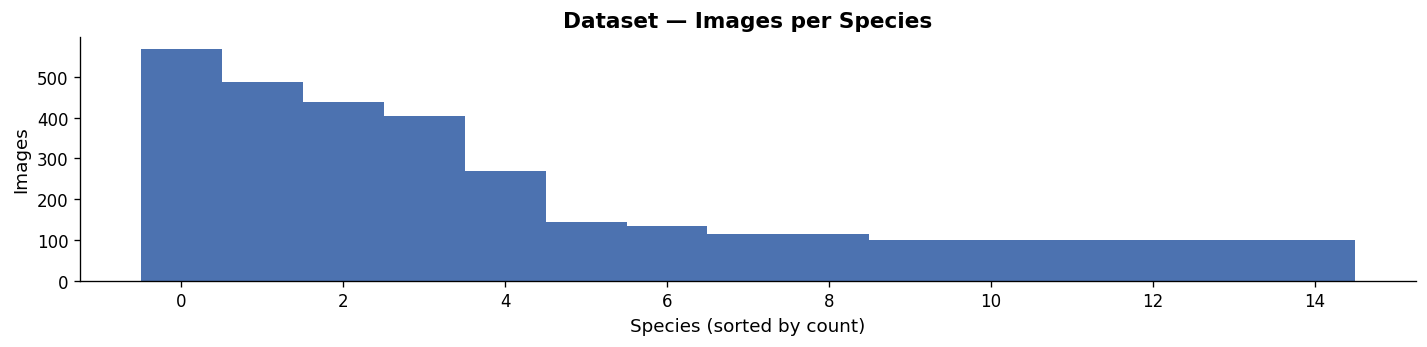

Min images/class: 100  |  Max: 569  |  Mean: 218.3


In [4]:
if os.path.exists(npz_path):
    data        = np.load(npz_path, allow_pickle=True)
    X           = data['features'].astype(np.float32)
    y           = data['labels']
    label_names = data['label_names']
else:
    X           = np.load(npy_path).astype(np.float32)
    y           = np.load(os.path.join(PROCESSED_DATA_PATH, 'labels.npy'))
    label_names = np.load(os.path.join(PROCESSED_DATA_PATH, 'label_names.npy'), allow_pickle=True)

print(f'Feature matrix : {X.shape}  dtype={X.dtype}')
print(f'Classes        : {len(np.unique(y))} ({len(label_names)} label names)')

# Class distribution plot
counts = np.bincount(y.astype(int))
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(counts)), sorted(counts, reverse=True), color=PALETTE[0], width=1.0)
ax.set_xlabel('Species (sorted by count)', fontsize=11)
ax.set_ylabel('Images', fontsize=11)
ax.set_title('Dataset — Images per Species', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Min images/class: {counts.min()}  |  Max: {counts.max()}  |  Mean: {counts.mean():.1f}')

## 5. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=RANDOM_SEED
)
print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

Train : (2619, 35134)
Test  : (655, 35134)


## 6. Preprocessing — StandardScaler → PCA

In [ ]:
print('Fitting StandardScaler...')
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Fitting PCA (n_components={N_COMPONENTS})...')
t0  = time.time()
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_train_t = pca.fit_transform(X_train_s)
X_test_t  = pca.transform(X_test_s)
print(f'PCA done in {time.time()-t0:.1f}s')

ev_ratio  = pca.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)
print(f'Variance retained : {ev_cumsum[-1]*100:.2f}%')

# ── PCA plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ev_ratio * 100, color=PALETTE[0], linewidth=1.2)
axes[0].fill_between(range(len(ev_ratio)), ev_ratio * 100, alpha=0.2, color=PALETTE[0])
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Per-component Explained Variance', fontweight='bold')

axes[1].plot(ev_cumsum * 100, color=PALETTE[1], linewidth=2)
axes[1].axhline(95, color='grey', linestyle='--', linewidth=1, label='95%')
axes[1].axhline(99, color='red',  linestyle='--', linewidth=1, label='99%')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

Fitting StandardScaler...
Fitting PCA (n_components=1000)...


## 7. Cross-Validation (optional — set `RUN_CV=False` to skip)

In [ ]:
cv_results = {}   # {model_type: scores_array}

CV_MODELS = {
    'linearsvc': LinearSVC(C=1.0, max_iter=10000, random_state=RANDOM_SEED,
                           class_weight='balanced', dual=False, tol=1e-3),
    'logreg'   : LogisticRegression(max_iter=1000, solver='saga',
                                    class_weight='balanced', random_state=RANDOM_SEED),
}
try:
    import lightgbm as lgb
    CV_MODELS['lgbm'] = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        n_jobs=-1, class_weight='balanced', random_state=RANDOM_SEED, verbose=-1
    )
except ImportError:
    print('LightGBM not installed — skipping lgbm CV')

if RUN_CV:
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    for name in MODEL_TYPES:
        if name not in CV_MODELS:
            continue
        print(f'\nCV → {name} ({CV_FOLDS}-fold)...')
        t0     = time.time()
        scores = cross_val_score(CV_MODELS[name], X_train_t, y_train,
                                 cv=skf, scoring='accuracy', n_jobs=-1)
        elapsed = time.time() - t0
        cv_results[name] = scores
        print(f'  Scores : {[f"{s*100:.2f}%" for s in scores]}')
        print(f'  Mean   : {scores.mean()*100:.2f}%  ±  {scores.std()*100:.2f}%  ({elapsed:.1f}s)')
else:
    print('CV skipped (RUN_CV=False)')

## 8. Train All Models

In [ ]:
TRAIN_MODELS = {}
train_times  = {}

for model_type in MODEL_TYPES:
    print(f'\n{"-"*50}\nTraining: {model_type}')
    t0 = time.time()

    if model_type == 'linearsvc':
        m = LinearSVC(C=2.0, max_iter=20000, random_state=RANDOM_SEED,
                      class_weight='balanced', dual=True, tol=1e-4)
    elif model_type == 'logreg':
        m = LogisticRegression(max_iter=5000, solver='saga',
                               class_weight='balanced', random_state=RANDOM_SEED)
    elif model_type == 'lgbm':
        try:
            import lightgbm as lgb
            m = lgb.LGBMClassifier(
                n_estimators=500, learning_rate=0.05, num_leaves=30,
                max_depth=5, n_jobs=-1, class_weight='balanced',
                random_state=RANDOM_SEED, verbose=-1
            )
        except ImportError:
            print('LightGBM not installed — skipping'); continue

    m.fit(X_train_t, y_train)
    elapsed = time.time() - t0
    TRAIN_MODELS[model_type] = m
    train_times[model_type]  = elapsed
    print(f'  Done in {elapsed:.1f}s')

## 9. Evaluate All Models

In [ ]:
eval_results = {}   # {model_type: {top1, top3, top5, y_pred, scores}}

for name, m in TRAIN_MODELS.items():
    y_pred = m.predict(X_test_t)

    if hasattr(m, 'decision_function'):
        raw_scores = m.decision_function(X_test_t)
    else:
        raw_scores = m.predict_proba(X_test_t)

    top1 = accuracy_score(y_test, y_pred)
    top3 = top_k_accuracy_score(y_test, raw_scores, k=3)
    top5 = top_k_accuracy_score(y_test, raw_scores, k=5)

    eval_results[name] = {
        'top1': top1, 'top3': top3, 'top5': top5,
        'y_pred': y_pred, 'raw_scores': raw_scores
    }
    print(f'{name:12s} → Top-1: {top1*100:.2f}%  Top-3: {top3*100:.2f}%  Top-5: {top5*100:.2f}%')

## 10. Save Artifacts (all models)

In [ ]:
for name, m in TRAIN_MODELS.items():
    out_dir = os.path.join(ARTIFACTS_PATH, name)
    os.makedirs(out_dir, exist_ok=True)
    joblib.dump(scaler,      os.path.join(out_dir, 'scaler.pkl'))
    joblib.dump(pca,         os.path.join(out_dir, 'pca.pkl'))
    joblib.dump(m,           os.path.join(out_dir, 'model.pkl'))
    joblib.dump(label_names, os.path.join(out_dir, 'label_names.pkl'))
    print(f'Saved: {out_dir}')

print('\nAll artifacts saved ✓')

---
# PART 2 — Model Comparison

## 11. Accuracy Comparison — All Models

In [ ]:
models_list = list(eval_results.keys())
top1_vals   = [eval_results[m]['top1'] * 100 for m in models_list]
top3_vals   = [eval_results[m]['top3'] * 100 for m in models_list]
top5_vals   = [eval_results[m]['top5'] * 100 for m in models_list]

x      = np.arange(len(models_list))
width  = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width, top1_vals, width, label='Top-1', color=PALETTE[0])
b2 = ax.bar(x,         top3_vals, width, label='Top-3', color=PALETTE[1])
b3 = ax.bar(x + width, top5_vals, width, label='Top-5', color=PALETTE[2])

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models_list], fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Model Comparison — Top-K Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 12. Cross-Validation Score Comparison

In [ ]:
if cv_results:
    fig, ax = plt.subplots(figsize=(8, 5))
    names_cv = list(cv_results.keys())
    means    = [cv_results[n].mean() * 100 for n in names_cv]
    stds     = [cv_results[n].std()  * 100 for n in names_cv]

    bars = ax.bar(names_cv, means, yerr=stds, capsize=6,
                  color=PALETTE[:len(names_cv)], edgecolor='white', linewidth=1.2)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
                f'{mean:.2f}% ± {std:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_ylabel(f'{CV_FOLDS}-Fold CV Accuracy (%)', fontsize=11)
    ax.set_title(f'Cross-Validation Results ({CV_FOLDS}-Fold Stratified)', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_xticklabels([n.upper() for n in names_cv], fontsize=11)
    plt.tight_layout(); plt.show()

    # Fold-level detail
    cv_df = pd.DataFrame({n: cv_results[n] * 100 for n in names_cv},
                         index=[f'Fold {i+1}' for i in range(CV_FOLDS)])
    cv_df.loc['Mean'] = cv_df.mean()
    cv_df.loc['Std']  = cv_df.std()
    display(cv_df.round(2))
else:
    print('CV was skipped (RUN_CV=False).')

## 13. Training Time Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
names_t = list(train_times.keys())
times_t = [train_times[n] for n in names_t]

bars = ax.barh(names_t, times_t, color=PALETTE[3:3+len(names_t)], edgecolor='white')
for bar, t in zip(bars, times_t):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Training Time (seconds)', fontsize=11)
ax.set_title('Training Time per Model', fontsize=13, fontweight='bold')
ax.set_yticklabels([n.upper() for n in names_t], fontsize=11)
plt.tight_layout(); plt.show()

## 14. Model Summary Table

In [ ]:
rows = []
for name in models_list:
    row = {
        'Model'         : name.upper(),
        'Top-1 Acc (%)'  : round(eval_results[name]['top1'] * 100, 2),
        'Top-3 Acc (%)'  : round(eval_results[name]['top3'] * 100, 2),
        'Top-5 Acc (%)'  : round(eval_results[name]['top5'] * 100, 2),
        'Train Time (s)' : round(train_times.get(name, float('nan')), 1),
    }
    if name in cv_results:
        row['CV Mean (%)'] = round(cv_results[name].mean() * 100, 2)
        row['CV Std (%)']  = round(cv_results[name].std()  * 100, 2)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')

# Highlight best per column
display(
    summary_df.style
    .highlight_max(subset=[c for c in summary_df.columns if 'Acc' in c or 'CV Mean' in c], color='#c6efce')
    .highlight_min(subset=['Train Time (s)'], color='#c6efce')
    .format(precision=2)
)

# Pick best model by Top-1 accuracy
BEST_MODEL = max(eval_results, key=lambda n: eval_results[n]['top1'])
print(f'\n🏆 Best model by Top-1 Accuracy: {BEST_MODEL.upper()} ({eval_results[BEST_MODEL]["top1"]*100:.2f}%)')

---
# PART 3 — Deep Evaluation of Best Model

In [ ]:
# Use the best model's results for the rest of the evaluation
model    = TRAIN_MODELS[BEST_MODEL]
y_pred   = eval_results[BEST_MODEL]['y_pred']
scores   = eval_results[BEST_MODEL]['raw_scores']
probs    = np.apply_along_axis(_softmax, 1, scores)
correct  = (y_pred == y_test)

print(f'Evaluating: {BEST_MODEL.upper()}')
print(f'Top-1 : {eval_results[BEST_MODEL]["top1"]*100:.2f}%')
print(f'Top-3 : {eval_results[BEST_MODEL]["top3"]*100:.2f}%')
print(f'Top-5 : {eval_results[BEST_MODEL]["top5"]*100:.2f}%')

## 15. Per-Class Classification Report

In [ ]:
target_names = label_names[np.unique(y_test).astype(int)]
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
report_df = pd.DataFrame({
    'Species'   : target_names,
    'Precision' : (precision * 100).round(2),
    'Recall'    : (recall    * 100).round(2),
    'F1-score'  : (f1        * 100).round(2),
    'Support'   : support
}).set_index('Species')

## 16. Top-10 Best & Worst Classes by F1

In [ ]:
top10_best  = report_df.sort_values('F1-score', ascending=False).head(10)
top10_worst = report_df.sort_values('F1-score').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, title, color in [
    (axes[0], top10_best,  'Top-10 Best  (by F1)', 'steelblue'),
    (axes[1], top10_worst, 'Top-10 Worst (by F1)', 'tomato')
]:
    short = [n.replace('_', ' ') for n in df.index]
    ax.barh(short, df['F1-score'], color=color, edgecolor='white')
    ax.set_xlabel('F1-score (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(df['F1-score']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

## 17. Confusion Matrix (Top-20 Classes by Frequency)

In [ ]:
N_CLASSES    = 20
class_counts = np.bincount(y_test.astype(int))
top_ids      = np.argsort(class_counts)[::-1][:N_CLASSES]
mask         = np.isin(y_test, top_ids)
cm           = confusion_matrix(y_test[mask], y_pred[mask], labels=top_ids)
cm_labels    = [label_names[i].replace('_', '\n') for i in top_ids]

fig, ax = plt.subplots(figsize=(16, 13))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(
    ax=ax, colorbar=True, cmap='Blues', xticks_rotation=90, values_format='d'
)
ax.set_title(f'Confusion Matrix — Top {N_CLASSES} Frequent Classes ({BEST_MODEL.upper()})',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 18. Confidence Distribution

In [ ]:
max_probs   = probs.max(axis=1)
threshold   = 0.6
above_thresh = max_probs >= threshold

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_probs[correct],  bins=40, alpha=0.7, color='steelblue', label='Correct')
axes[0].hist(max_probs[~correct], bins=40, alpha=0.7, color='tomato',    label='Incorrect')
axes[0].axvline(threshold, color='grey', linestyle='--', linewidth=1.2, label=f'Threshold ({threshold})')
axes[0].set_xlabel('Max Confidence (softmax prob)'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution', fontweight='bold'); axes[0].legend(fontsize=9)

buckets, bucket_acc, bucket_lbl = np.arange(0, 1.05, 0.1), [], []
for lo, hi in zip(buckets[:-1], buckets[1:]):
    mask = (max_probs >= lo) & (max_probs < hi)
    if mask.sum() > 0:
        bucket_acc.append(correct[mask].mean() * 100)
        bucket_lbl.append(f'{lo:.1f}–{hi:.1f}')

axes[1].bar(range(len(bucket_acc)), bucket_acc, color=PALETTE[2], edgecolor='white')
axes[1].set_xticks(range(len(bucket_lbl)))
axes[1].set_xticklabels(bucket_lbl, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 105)
axes[1].set_title('Accuracy per Confidence Bucket', fontweight='bold')

plt.tight_layout(); plt.show()
print(f'Above threshold ({threshold}): {above_thresh.sum()} / {len(max_probs)} ({above_thresh.mean()*100:.1f}%)')
print(f'Accuracy ABOVE threshold : {correct[above_thresh].mean()*100:.2f}%')
print(f'Accuracy BELOW threshold : {correct[~above_thresh].mean()*100:.2f}%')

## 19. Venomous vs Non-venomous Classification

In [ ]:
venom_true = np.array([is_venomous(label_names[int(i)])[0] for i in y_test])
venom_pred = np.array([is_venomous(label_names[int(i)])[0] for i in y_pred])
venom_acc  = accuracy_score(venom_true, venom_pred)
cm_v       = confusion_matrix(venom_true, venom_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([venom_true.sum(), (~venom_true).sum()],
            labels=['Venomous', 'Non-venomous'],
            colors=[PALETTE[3], PALETTE[0]],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Test Set Distribution', fontweight='bold')

ConfusionMatrixDisplay(cm_v, display_labels=['Non-venomous', 'Venomous']).plot(
    ax=axes[1], colorbar=False, cmap='YlOrRd'
)
axes[1].set_title(f'Venomous/Non-venomous CM  (Acc={venom_acc*100:.2f}%)', fontweight='bold')
plt.tight_layout(); plt.show()

print(classification_report(venom_true, venom_pred,
      target_names=['Non-venomous', 'Venomous'], zero_division=0))

## 20. Per-Species Accuracy Distribution

In [ ]:
class_accs = {label_names[int(cls_id)]: correct[y_test == cls_id].mean() * 100
              for cls_id in np.unique(y_test) if (y_test == cls_id).sum() >= 2}

acc_df = pd.DataFrame.from_dict(class_accs, orient='index', columns=['Accuracy (%)'])\
                     .sort_values('Accuracy (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(acc_df['Accuracy (%)'], bins=20, color=PALETTE[2], edgecolor='white')
ax.axvline(acc_df['Accuracy (%)'].mean(), color='tomato', linestyle='--',
           label=f"Mean = {acc_df['Accuracy (%)'].mean():.1f}%")
ax.set_xlabel('Per-class Accuracy (%)'); ax.set_ylabel('Number of Classes')
ax.set_title('Distribution of Per-class Accuracy', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Mean  : {acc_df["Accuracy (%)"].mean():.2f}%')
print(f'Median: {acc_df["Accuracy (%)"].median():.2f}%')
acc_df.head(10)

## 21. Sample Visual Predictions

In [ ]:
def get_sample_images(n=12, seed=RANDOM_SEED):
    random.seed(seed)
    folders = sorted([d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])
    samples, attempts = [], 0
    while len(samples) < n and attempts < 500:
        sp   = random.choice(folders)
        imgs = [f for f in os.listdir(os.path.join(DATASET_PATH, sp))
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if imgs:
            samples.append((os.path.join(DATASET_PATH, sp, random.choice(imgs)), sp))
        attempts += 1
    return samples

# Load the best model's artifacts for the SnakeClassifier wrapper
best_artifacts = os.path.join(ARTIFACTS_PATH, BEST_MODEL)
classifier = SnakeClassifier(artifacts_dir=best_artifacts)
samples    = get_sample_images(n=12)

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
for ax, (img_path, true_species) in zip(axes.flatten(), samples):
    img_rgb = cv2.cvtColor(cv2.resize(cv2.imread(img_path), (256, 256)), cv2.COLOR_BGR2RGB)
    result  = classifier.predict(img_path)
    ax.imshow(img_rgb); ax.axis('off')
    if 'error' in result:
        ax.set_title(f'ERROR', color='red', fontsize=7); continue
    t1      = result['top_3'][0]
    is_ok   = t1['species'] == true_species
    title   = (f'True: {true_species.replace("_", " ")}\n'
               f'Pred: {t1["species"].replace("_", " ")}\n'
               f'Conf: {t1["probability"]:.3f}  {"✓" if is_ok else "✗"}')
    ax.set_title(title, fontsize=7.5, color='green' if is_ok else 'red', fontweight='bold')

plt.suptitle(f'Sample Predictions — {BEST_MODEL.upper()}  (Green=Correct  Red=Incorrect)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 22. Top-3 Breakdown — Single Example

In [ ]:
random.seed(RANDOM_SEED + 7)
img_path, true_species = random.choice(get_sample_images(n=50))
result  = classifier.predict(img_path)
img_rgb = cv2.cvtColor(cv2.resize(cv2.imread(img_path), (256, 256)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 2]})
axes[0].imshow(img_rgb); axes[0].axis('off')
axes[0].set_title(f'True: {true_species.replace("_", " ")}', fontsize=10, fontweight='bold')

top3   = result['top_3']
names3 = [r['species'].replace('_', ' ') for r in top3]
probs3 = [r['probability'] for r in top3]
cols3  = ['tomato' if r['is_venomous'] else 'steelblue' for r in top3]

bars = axes[1].barh(names3[::-1], probs3[::-1], color=cols3[::-1], height=0.5, edgecolor='white')
for bar, p in zip(bars, probs3[::-1]):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{p:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].axvline(0.6, color='grey', linestyle='--', linewidth=1.2, label='Safety threshold')
axes[1].set_xlabel('Confidence (softmax probability)'); axes[1].set_xlim(0, 1.0)
axes[1].set_title('Top-3 Predictions  (Red=Venomous  Blue=Non-venomous)', fontweight='bold')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'Safety: {result["safety_message"]}')
for i, r in enumerate(top3, 1):
    tag = '☠ VENOMOUS' if r['is_venomous'] else '✓ non-venomous'
    print(f'  {i}. {r["species"]:<42}  prob={r["probability"]:.4f}  {tag}')

## 23. Final Summary Dashboard

In [ ]:
top1 = eval_results[BEST_MODEL]['top1']
top3_acc = eval_results[BEST_MODEL]['top3']
top5_acc = eval_results[BEST_MODEL]['top5']

summary = {
    'Metric': [
        'Best Model',
        'Top-1 Accuracy',
        'Top-3 Accuracy',
        'Top-5 Accuracy',
        'CV Mean Accuracy (best model)',
        'Venomous/Non-venomous Accuracy',
        'Mean Per-class Accuracy',
        'PCA Variance Retained',
        'Samples Above Confidence Threshold (0.6)',
        'Test Samples',
        'Number of Classes',
        'Training Time (best model)',
    ],
    'Value': [
        BEST_MODEL.upper(),
        f'{top1 * 100:.2f}%',
        f'{top3_acc * 100:.2f}%',
        f'{top5_acc * 100:.2f}%',
        f'{cv_results[BEST_MODEL].mean()*100:.2f}%' if BEST_MODEL in cv_results else 'N/A',
        f'{venom_acc * 100:.2f}%',
        f'{acc_df["Accuracy (%)"].mean():.2f}%',
        f'{pca.explained_variance_ratio_.sum() * 100:.2f}%',
        f'{above_thresh.sum()} ({above_thresh.mean()*100:.1f}%)',
        str(len(y_test)),
        str(len(label_names)),
        f'{train_times.get(BEST_MODEL, 0):.1f}s',
    ]
}

display(
    pd.DataFrame(summary).set_index('Metric')
    .style.set_properties(**{'text-align': 'left', 'font-size': '13px'})
)